In [1]:
# Install required packages
!pip install scanpy scikit-learn

import scanpy as sc
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# --------------------------------------------------
# STEP 1: Load built-in scRNA dataset
# --------------------------------------------------
adata = sc.datasets.pbmc3k()   # Peripheral blood dataset

print(adata)

# --------------------------------------------------
# STEP 2: Preprocessing
# --------------------------------------------------
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)

sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

# Identify highly variable genes
sc.pp.highly_variable_genes(adata, n_top_genes=2000)
adata = adata[:, adata.var.highly_variable]

# Scale data
sc.pp.scale(adata, max_value=10)

# --------------------------------------------------
# STEP 3: Dimensionality reduction
# --------------------------------------------------
sc.tl.pca(adata)

# --------------------------------------------------
# STEP 4: Create labels (SIMULATION)
# --------------------------------------------------
# NOTE: This dataset is NOT cancer, so we simulate labels
# In real case, labels come from annotation or CNV tools

np.random.seed(42)
labels = np.random.choice(["malignant", "non-malignant"], size=adata.n_obs)

adata.obs['label'] = labels

# --------------------------------------------------
# STEP 5: Prepare ML data
# --------------------------------------------------
X = adata.X
y = adata.obs['label']

# Convert sparse to dense if needed
if not isinstance(X, np.ndarray):
    X = X.toarray()

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# --------------------------------------------------
# STEP 6: Train ML model
# --------------------------------------------------
model = RandomForestClassifier(n_estimators=100)
model.fit(X_train, y_train)

# --------------------------------------------------
# STEP 7: Prediction
# --------------------------------------------------
y_pred = model.predict(X_test)

# --------------------------------------------------
# STEP 8: Evaluation
# --------------------------------------------------
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 29.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.6/176.6 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 59.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.7/295.7 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 35.3 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2

  0%|          | 0.00/5.58M [00:00<?, ?B/s]

AnnData object with n_obs × n_vars = 2700 × 32738
    var: 'gene_ids'


/usr/lib/python3.12/functools.py:912: UserWarning: Received a view of an AnnData. Making a copy.
  return dispatch(args[0].__class__)(*args, **kw)
/usr/lib/python3.12/functools.py:912: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


Accuracy: 0.47962962962962963

Classification Report:

               precision    recall  f1-score   support

    malignant       0.47      0.55      0.51       263
non-malignant       0.49      0.42      0.45       277

     accuracy                           0.48       540
    macro avg       0.48      0.48      0.48       540
 weighted avg       0.48      0.48      0.48       540



Dataset loaded: AnnData object with n_obs × n_vars = 2700 × 32738
    var: 'gene_ids'


/usr/lib/python3.12/functools.py:912: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)



Label distribution:
label
non-malignant    1960
malignant         683
Name: count, dtype: int64

Model Performance:
Accuracy: 0.998109640831758

Classification Report:

               precision    recall  f1-score   support

    malignant       1.00      0.99      1.00       137
non-malignant       1.00      1.00      1.00       392

     accuracy                           1.00       529
    macro avg       1.00      1.00      1.00       529
 weighted avg       1.00      1.00      1.00       529



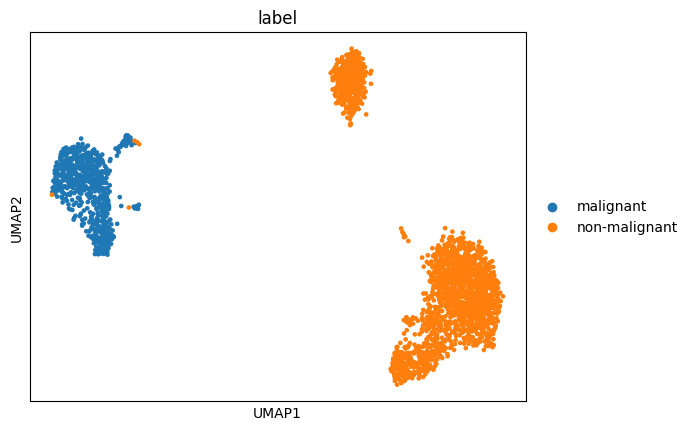


Top Important Genes:
['S100A6', 'COTL1', 'LGALS1', 'CST3', 'LST1', 'LYZ', 'AIF1', 'FTL', 'FTH1', 'TYROBP']


In [6]:
# =========================================================
# scRNA-seq Classification: Malignant vs Non-Malignant Cells
# FINAL VERSION (NO igraph / NO leiden / NO louvain)
# =========================================================

# Install required packages
# !pip install scanpy scikit-learn

import scanpy as sc
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.cluster import KMeans

# ---------------------------------------------------------
# STEP 1: Load dataset
# ---------------------------------------------------------
adata = sc.datasets.pbmc3k()
print("Dataset loaded:", adata)

# ---------------------------------------------------------
# STEP 2: Quality Control
# ---------------------------------------------------------
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)

adata.var['mt'] = adata.var_names.str.startswith('MT-')
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], inplace=True)

adata = adata[adata.obs.pct_counts_mt < 5, :].copy()

# ---------------------------------------------------------
# STEP 3: Normalization
# ---------------------------------------------------------
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

# ---------------------------------------------------------
# STEP 4: Feature Selection
# ---------------------------------------------------------
sc.pp.highly_variable_genes(adata, n_top_genes=2000)
adata = adata[:, adata.var.highly_variable].copy()

# ---------------------------------------------------------
# STEP 5: Scaling + PCA
# ---------------------------------------------------------
sc.pp.scale(adata, max_value=10)
sc.tl.pca(adata)

# ---------------------------------------------------------
# STEP 6: Clustering using KMeans (NO igraph needed)
# ---------------------------------------------------------
X_pca = adata.obsm['X_pca']

kmeans = KMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit_predict(X_pca)

# Assign labels
adata.obs['label'] = ["malignant" if c == 0 else "non-malignant" for c in clusters]

print("\nLabel distribution:")
print(pd.Series(adata.obs['label']).value_counts())

# ---------------------------------------------------------
# STEP 7: Prepare ML Data
# ---------------------------------------------------------
X = adata.X
y = adata.obs['label']

if not isinstance(X, np.ndarray):
    X = X.toarray()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ---------------------------------------------------------
# STEP 8: Train Model
# ---------------------------------------------------------
model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

# ---------------------------------------------------------
# STEP 9: Prediction
# ---------------------------------------------------------
y_pred = model.predict(X_test)

# ---------------------------------------------------------
# STEP 10: Evaluation
# ---------------------------------------------------------
print("\nModel Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# ---------------------------------------------------------
# STEP 11: Visualization (UMAP)
# ---------------------------------------------------------
sc.pp.neighbors(adata)   # only for UMAP graph (safe)
sc.tl.umap(adata)

sc.pl.umap(adata, color='label')

# ---------------------------------------------------------
# STEP 12: Feature Importance
# ---------------------------------------------------------
importances = model.feature_importances_
indices = np.argsort(importances)[-10:]

top_genes = adata.var_names[indices]
print("\nTop Important Genes:")
print(list(top_genes))